# 02 Q2 Routing Control

Paper-ready single-subfigure exports for Q2.

In [98]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import real_final_viz_helpers as viz
importlib.reload(viz)

PALETTE = viz.PALETTE
apply_style = viz.apply_style
bar_line_panel = viz.bar_line_panel
dataset_label = viz.dataset_label
load_csv = viz.load_csv
mark_ours_first = viz.mark_ours_first
legend_strip_axes = viz.legend_strip_axes
single_subfigure_axes = viz.single_subfigure_axes
add_legend_strip = viz.add_legend_strip

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = Path('/workspace/FeaturedMoE/writing/260419_real_final_exp')
FIG_DIR = Path('/workspace/FeaturedMoE/writing/ACM_template/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
apply_style()

In [99]:
q2_quality = load_csv('q2_quality.csv')

def select_best_hparam_then_average(df):
    scored = (
        df.groupby(['dataset', 'variant_label', 'variant_order', 'base_rank'], as_index=False)
        [['best_valid_seen_mrr20', 'test_ndcg20', 'test_hit10']]
        .mean()
    )
    best = (
        scored.sort_values(
            ['dataset', 'variant_order', 'best_valid_seen_mrr20', 'test_ndcg20', 'test_hit10', 'base_rank'],
            ascending=[True, True, False, False, False, True],
            kind='stable',
        )
        .drop_duplicates(['dataset', 'variant_label', 'variant_order'], keep='first')
        .sort_values(['dataset', 'variant_order'], kind='stable')
        .reset_index(drop=True)
    )
    return best

quality_plot = select_best_hparam_then_average(q2_quality)
variant_label_map = {
    'Behavior-guided': 'Behavior-guided',
    'Shared FFN': 'Shared FFN',
    'Hidden only': 'Hidden router',
    'Fusion bias': 'Fusion bias',
    'Mixed': 'Mixed H+B',
}
quality_plot['variant_display'] = quality_plot['variant_label'].map(variant_label_map).fillna(quality_plot['variant_label'])
display_order = ['Behavior-guided', 'Hidden router', 'Mixed H+B', 'Fusion bias', 'Shared FFN']
legend_order = mark_ours_first(display_order)
quality_plot['variant_display'] = pd.Categorical(quality_plot['variant_display'], categories=display_order, ordered=True)
quality_plot = quality_plot.sort_values(['dataset', 'variant_display'], kind='stable').reset_index(drop=True)
bar_palette = {
    'Behavior-guided': PALETTE['route'],
    'Hidden router': PALETTE['orange'],
    'Mixed H+B': PALETTE['rose'],
    'Fusion bias': PALETTE['plum'],
    'Shared FFN': PALETTE['blue'],
}
legend_colors = [bar_palette[label] for label in display_order]
q2_dynamic = quality_plot[quality_plot['dataset'] == 'KuaiRecLargeStrictPosV2_0.2'].copy()
q2_stable = quality_plot[quality_plot['dataset'] == 'foursquare'].copy()
print('prepared Q2 rows', len(quality_plot))

prepared Q2 rows 20


[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q2_routing_control_a.pdf


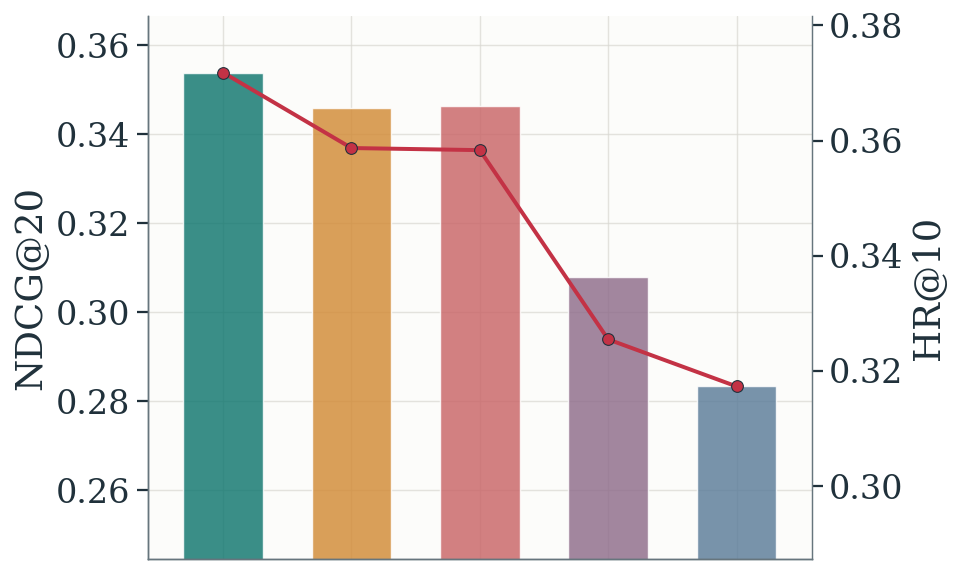

In [100]:
fig, ax = single_subfigure_axes()
bar_line_panel(
    q2_dynamic,
    category_col='variant_display',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    ax=ax,
    order=display_order,
    xrotation=0,
    palette_override=bar_palette,
    show_xticklabels=False,
    add_metric_legend_box=False,
)
fig.savefig(FIG_DIR / 'fig_q2_routing_control_a.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q2_routing_control_a.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q2_routing_control_b.pdf


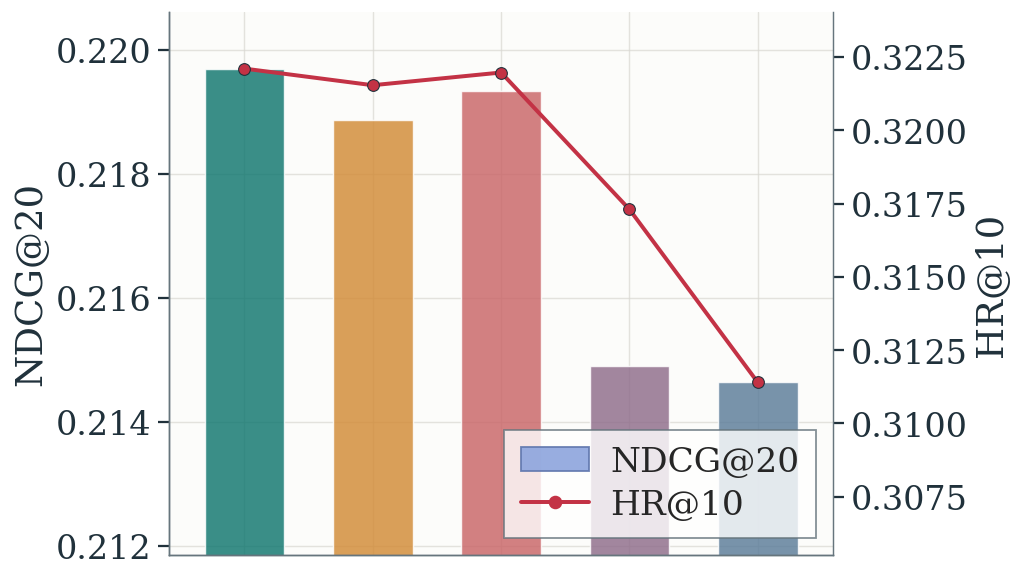

In [101]:
fig, ax = single_subfigure_axes()
bar_line_panel(
    q2_stable,
    category_col='variant_display',
    ndcg_col='test_ndcg20',
    hr_col='test_hit10',
    ax=ax,
    order=display_order,
    xrotation=0,
    palette_override=bar_palette,
    show_xticklabels=False,
    add_metric_legend_box=True,
)
fig.savefig(FIG_DIR / 'fig_q2_routing_control_b.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q2_routing_control_b.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/fig_q2_routing_control_legend.pdf


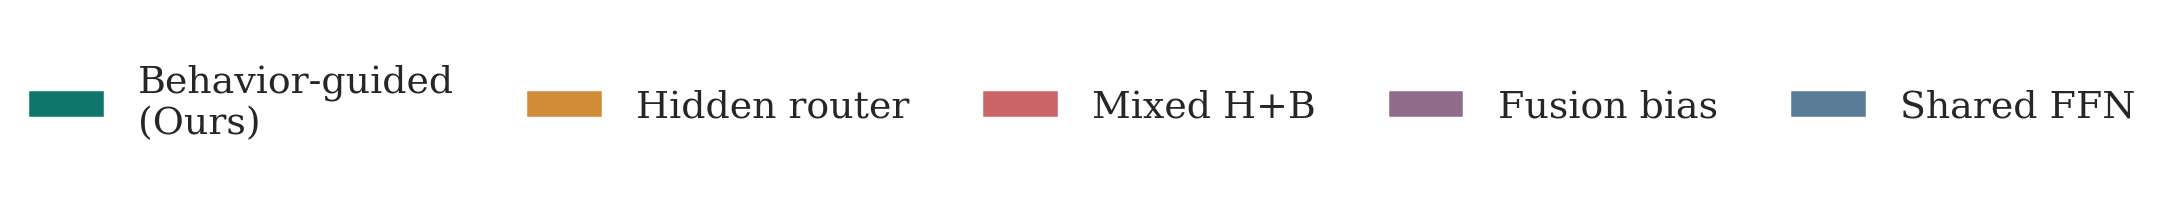

In [102]:
fig, ax = legend_strip_axes()
add_legend_strip(ax, legend_order, legend_colors)
fig.savefig(FIG_DIR / 'fig_q2_routing_control_legend.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'fig_q2_routing_control_legend.pdf')
plt.show()